In [29]:
%pip install -qU pypdf langchain-community langchain-text-splitter

/home/swjeong/langchain/langgraph/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
from langchain_community.document_loaders import PyPDFLoader
pdf_file_path = "./income_tax.pdf"
loader = PyPDFLoader(pdf_file_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)


In [31]:
%pip install -q py-zerox

/home/swjeong/langchain/langgraph/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
from dotenv import load_dotenv

load_dotenv()

True

In [33]:
%pip install -q nest_asyncio

/home/swjeong/langchain/langgraph/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
import nest_asyncio
nest_asyncio.apply()

In [35]:
from pyzerox import zerox
import os
import json
import asyncio

### Model Setup (Use only Vision Models) Refer: https://docs.litellm.ai/docs/providers ###

## placeholder for additional model kwargs which might be required for some models
kwargs = {}

## system prompt to use for the vision model
custom_system_prompt = None

# to override
# custom_system_prompt = "For the below PDF page, do something..something..." ## example

###################### Example for OpenAI ######################
model = "gpt-4o-mini" ## openai model

###################### For other providers refer: https://docs.litellm.ai/docs/providers ######################

# Define main async entrypoint
async def main():
    file_path = "./income_tax.pdf" ## local filepath and file URL supported

    ## process only some pages or all
    select_pages = None ## None for all, but could be int or list(int) page numbers (1 indexed)

    output_dir = "./documents" ## directory to save the consolidated markdown file
    result = await zerox(file_path=file_path, model=model, output_dir=output_dir,
                        custom_system_prompt=custom_system_prompt,select_pages=select_pages, **kwargs)
    return result


# run the main function:
result = asyncio.run(main())

# print markdown result
print(result)

ZeroxOutput(completion_time=228586.55, file_name='income_tax', input_tokens=5052149, output_tokens=139814, pages=[Page(content='# 소득세법\n\n[시행 2026. 4. 21.] [법률 제21548호, 2026. 4. 21, 일부개정]\n\n재정경제부 (소득세과) 044-215-4312  \n재정경제부 (소득세과) 044-215-4216  \n재정경제부 (금융세제과) 044-215-4233  \n재정경제부 (소득세제과) 044-215-4217  \n재정경제부 (국제조세제도과) 044-215-4651  \n\n## 제1장 총칙\n<개정 2009. 12. 31.>\n\n## 제1조(목적)\n이 법은 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세함으로써 조세부담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 한다.  \n[본신설 2009. 12. 31.]  \n[종전 제1조는 제1조로 이동 <2009. 12. 31.>]\n\n## 제2조(정의)\n① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2010. 12. 27, 2014. 12. 23, 2018. 12. 31.>  \n1. "거주자"란 국내에 주소를 두나 183일 이상의 거소(居所)를 둔 개인을 말한다.  \n2. "비거주자"란 거주자가 아닌 개인을 말한다.  \n3. "내국법인"이란 법인세법 제2조제1호에 따른 내국법인을 말한다.  \n4. "외국법인"이란 법인세법 제2조제3호에 따른 외국법인을 말한다.  \n5. "사업자"란 사업소득이 있는 거주자를 말한다.  \n6. 이와 같이 정의하는 소득ㆍ가속소득ㆍ비거주자의 규준은 대통령령으로 정한다.  \n[본신설 2009. 12. 31.]\n\n## 제2조(납세의무)\n② 다음 각 호의 어느 하나에 해당하는 개인은 이 법에 따라 각각의 소득에 대한 소득세를 납부할 의무를 진다.  \n1. 거주자  \n2. 비

In [36]:
%pip install -q "unstructured[md] nltk"

/home/swjeong/langchain/langgraph/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 100,
    separators =['\n\n', '\n']
)

In [ ]:
from langchain_community.document_loaders import UnstructuredMarkdownLoader

markdown_path = "./documents/income_tax.md"
loader = UnstructuredMarkdownLoader(markdown_path)

document_list = loader.load_and_split(text_splitter)

document_list[43]
#하지만 제대로된 데이터를 못가져올 수 있음 md -> txt -> load -> split 해야함함

Document(metadata={'source': './documents/income_tax.md'}, page_content='소득세법\n\n다음 각 목의 어느 하나에 해당하는 것이(이하 이 조 및 제129조에서 “간접투자회사등”이라 한다)로부터 지급받은 소득은 다음과 같다 가. 자본시장과 금융투자업에 관한 법률, 이른바 투자회사, 투자목적회사, 투자유한회사, 투자자합작회사(같은 법 제40조제19항제1호의 기관전환 사모집합투자기구를 제외한다), 투자신탁, 투자신탁 및 투자회차본차 나. 부동산투자회사법에 따른 기업구조조정 부동산투자회사 및 외국관리 부동산투자회사 다. 단일세법, 제205조제2항에 따라 내부거래로 분류 신탁재산 라. 간접투자회사등이 기타자산에 대해서 이해관계자(일반법 제75조제1항 및 제76조제1항에 따른 외국법인에게(간접투자외국법인에서) 발행하는 구조를 취하고 있는 경우를 포함하는 이루어 이 조 제129조에서 “간접투자외국법인에세”를 포함한 경우\n\n처음 제116항을 적용할 때 기저자가 간접투자회사등으로부터 지급받은 소득과 종합소득세출의 제외에 공제되는 금액은 다음 각 항목의 금액으로 한다. <개정 2024. 12. 31., 2025. 12. 23.>\n\n간접투자회사등으로부터 지급받은 소득: 자본시장과 금융투자업에 관한 법률, 제23조제16항에 따른 기준가격(간접투자외국법인에서 자산의 가격을 감안하며, 이하 이 조 제129조에서 “세액기준가격”이라 한다) 기준으로 계산된 금액. 다만, “자본시장과 금융투자업에 관한 법률”에 따라 증권시장이 이른바 “증권시장”이 한다에 상응된 간접투자회사등의 증권의 매도에 따라 간접투자회사등으로부터 지급받은 소득은 대통령으로 정하는 바에 따라 계산한 금액으로 한다.\n\n중소득소득세출 또는 중소득소득세출세에서 공제하는 금액: 다음 각 목의 금액을 고려하여 대통령으로 정하는 것 가. 제101조 소득에 대하여 제129조제15항에 따라 원천징수 시 계산할 때 같은 계산법 제206조에 따른 계산금액 합계액 나. 제

In [45]:
%pip install -q markdown html2text beautifulsoup4

/home/swjeong/langchain/langgraph/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [48]:
import markdown
from bs4 import BeautifulSoup

text_path = './documents/income_tax.txt'
with open(markdown_path, 'r', encoding = 'utf-8') as md_file:
    md_content = md_file.read()

html_content = markdown.markdown(md_content)

soup = BeautifulSoup(html_content, 'html.parser')
text_content = soup.get_text()

with open(text_path, 'w', encoding='utf-8') as txt_file:
    txt_file.write(text_content)

print("Markdown converted to plain text successfully!")

Markdown converted to plain text successfully!


In [49]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader(text_path)
document_list = loader.load_and_split(text_splitter)

In [50]:
document_list[39]

Document(metadata={'source': './documents/income_tax.txt'}, page_content='부동산 또는 부동산의 권리를 대상하는 사업  \n공사업체 또는 광물자원을 대상으로 하는 사업  \n체결에 관한 권리를 대하여 사업으로서 대통령령으로 정하는 사업  \n\n부동산임대업에서 발생한 결손금과 제15항에 따라 발생할 경우 해당 과세기간의 소득금액을 계산할 때에는 해당 이익결손금이 발생한 과세기간으로부터 실연다. 다만,국세기본법 제26조에 의하여는 그렇지 아니하다.\n<개정 2014. 12. 23., 2020. 12. 29.>\n\n\n제1항 제3호에 따라 귀하가 있는 이익결손금은 사업소득금액, 근로소득금액, 연금소득금액, 기타소득금액, 사업소득금액 및 배당소득금액에 순서대로 정리된다.\n② 제3항은 해당 과세기간의 소득금액에 대하여 주식사전자정에 따라 160조 및 161조에 따라 달리. 기획재정부와 종합류에 의하여 아닌 신고를 형_contention 하며 아래 같은 것을 제35조 항목에 해당 주제 소비하는 경우에는 그러하지 아니한다. 다만, 천재지변이나 박의 질병으로 장난을 박의 증범령 발의 시 추출된 신호나 주제소규정에 해당하는 경우에는 그러하지 아니하다.')

In [51]:
%pip install -q langchain-chroma

/home/swjeong/langchain/langgraph/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [52]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model='text-embedding-3-large')

In [53]:
from langchain_chroma import Chroma

vector_store = Chroma.from_documents(
    documents=document_list,
    embedding=embeddings,
    collection_name = 'income_tax_collection',
    persist_directory = './income_tax_collection'
)

In [54]:
retriever = vector_store.as_retriever(search_kwargs={'k':3})

In [55]:
query = "연봉 5천만원 직장인의 소득세는?"
retriever.invoke(query)

[Document(metadata={'source': './documents/income_tax.txt'}, page_content="3. 근로소득에 대해서는 기본세율. 단, 임금근로자의 근로소득에 대해서는 100분의 6으로 한다.\n4. 공적연금소득에 대해서는 기본세율\n   5.2. 제20조의3제1항제2호나 및 다목에 따른 연금계획 남입액어 및 용실계달에 따른 증가된 금액을 연금수령한 연금소득에 대해서는 다음 각 목의 구분에 따른 세율. 이 경우 각 목의 요건을 동시에 충족하는 때에는 낮은 세율을 적용한다.\n      가. 연금수령자가 나이에 따른 다음의 세율\n      | 나이(연금수급형 갱신) | 세율         |\n      |----------------------|--------------|\n      | 70세 미만           | 100분의 5    |\n      | 70세 이상           | 80세 미만    | 100분의 3    |\n      | 80세 이상           | 100분의 3    |\n나. 삭제 <2014. 12. 23.>\n다. 사망할 때까지 연금수령하는 대통령령으로 정의하는 중심계약에 따라 받는 연금소득에 대해서는 100분의 3 \n5의3. 제2023의제31항제1호조의 규정에 따라 퇴직소득을 연금수령하는 연금소득에 대해서는 다음 각 목의 구분에 따라 \n세웁니다. 이 경우 연금 실제 수령액 및 연금외수령 원천징수세율을 계획적인 내용으로 정의합니다. \n가. 연금 실제 수령연차가 10년 이하인 경우: 연금외수령 원천징수세율의 100분의 70\n나. 연금 실제 수령연차가 10년을 초과하고 20년 이하인 경우: 연금외수령 원천징수세율의 100분의 60\n다. 연금 실제 수령연차가 20년을 초과하는 경우: 연금외수령 원천징수세율의 100분의 50\n6. 기타소득에 대해서는 다음의 규정을 적용하는 사항. 다만, 제시효율을 적용받는 경우는 제외한다. \n가. 제41조제3항제3호라 및 마목에 해당하는 

In [56]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [ ]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [63]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [59]:
# Create a LangSmith API in Settings > API Keys
# Make sure API key env var is set:
# import os; os.environ["LANGSMITH_API_KEY"] = "<your-api-key>"
from langsmith import Client
from langchain_openai import ChatOpenAI
client = Client()
prompt = client.pull_prompt("rlm/rag-prompt")
llm = ChatOpenAI(model='gpt-4o')

/home/swjeong/langchain/langgraph/.venv/lib/python3.13/site-packages/langsmith/client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [60]:
def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

In [64]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

In [65]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)

In [67]:
graph = graph_builder.compile()

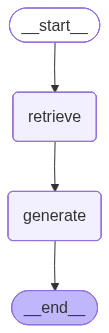

In [68]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
#시퀀스는 일일이 노드와 엣지를 추가하지 않고 아래와 같이 가능
sequence_graph_builder = StateGraph(AgentState).add_sequence([retrieve, generate])

In [73]:
sequence_graph_builder.add_edge(START, 'retrieve')
sequence_graph_builder.add_edge('generate', END)
sequence_graph = sequence_graph_builder.compile()

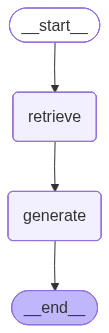

In [75]:
display(Image(sequence_graph.get_graph().draw_mermaid_png()))

In [76]:
initial_state = {'query': query}
graph.invoke(initial_state)

{'query': '연봉 5천만원 직장인의 소득세는?',
 'context': [Document(metadata={'source': './documents/income_tax.txt'}, page_content="3. 근로소득에 대해서는 기본세율. 단, 임금근로자의 근로소득에 대해서는 100분의 6으로 한다.\n4. 공적연금소득에 대해서는 기본세율\n   5.2. 제20조의3제1항제2호나 및 다목에 따른 연금계획 남입액어 및 용실계달에 따른 증가된 금액을 연금수령한 연금소득에 대해서는 다음 각 목의 구분에 따른 세율. 이 경우 각 목의 요건을 동시에 충족하는 때에는 낮은 세율을 적용한다.\n      가. 연금수령자가 나이에 따른 다음의 세율\n      | 나이(연금수급형 갱신) | 세율         |\n      |----------------------|--------------|\n      | 70세 미만           | 100분의 5    |\n      | 70세 이상           | 80세 미만    | 100분의 3    |\n      | 80세 이상           | 100분의 3    |\n나. 삭제 <2014. 12. 23.>\n다. 사망할 때까지 연금수령하는 대통령령으로 정의하는 중심계약에 따라 받는 연금소득에 대해서는 100분의 3 \n5의3. 제2023의제31항제1호조의 규정에 따라 퇴직소득을 연금수령하는 연금소득에 대해서는 다음 각 목의 구분에 따라 \n세웁니다. 이 경우 연금 실제 수령액 및 연금외수령 원천징수세율을 계획적인 내용으로 정의합니다. \n가. 연금 실제 수령연차가 10년 이하인 경우: 연금외수령 원천징수세율의 100분의 70\n나. 연금 실제 수령연차가 10년을 초과하고 20년 이하인 경우: 연금외수령 원천징수세율의 100분의 60\n다. 연금 실제 수령연차가 20년을 초과하는 경우: 연금외수령 원천징수세율의 100분의 50\n6. 기타소득에 대해서는 다음의 규정을 적용하는 사항. 다만, 제시효율을